<a href="https://colab.research.google.com/github/likithams09/Generative-AI-Lab/blob/main/Text_to_Image_Stable_Diffusionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TEXT TO IMAGE GENERATION USING STABLE DIFFUSION

Step 1:Install libraries

In [8]:
!pip install -q diffusers transformers accelerate safetensors

Step 2:Check GPU

In [1]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


Step 3:Import the model

In [2]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Step 4:Give the text prompt

In [17]:
prompt = """
A beautiful young fairy-tale princess named Cinderella,
close-up professional portrait, centered face, looking directly at the camera,
symmetrical natural facial features, two clear blue eyes,
proportional nose and lips, natural facial anatomy,
soft elegant expression and gentle smile,
smooth realistic skin texture,
long golden-blonde wavy hair, delicate silver tiara,
wearing an elegant pale blue ball gown,
sparkling diamond necklace and small earrings,
luxurious royal ballroom softly blurred in the background,
soft cinematic studio lighting,
beautiful natural face, realistic eyes,
highly detailed professional portrait photography,
sharp focus on the face, shallow depth of field,
photorealistic, high quality
"""

Step 5:Generate one human face

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['gown , sparkling diamond necklace and small earrings , luxurious royal ballroom softly blurred in the background , soft cinematic studio lighting , beautiful natural face , realistic eyes , highly detailed professional portrait photography , sharp focus on the face , shallow depth of field , photorealistic , high quality']


  0%|          | 0/30 [00:00<?, ?it/s]

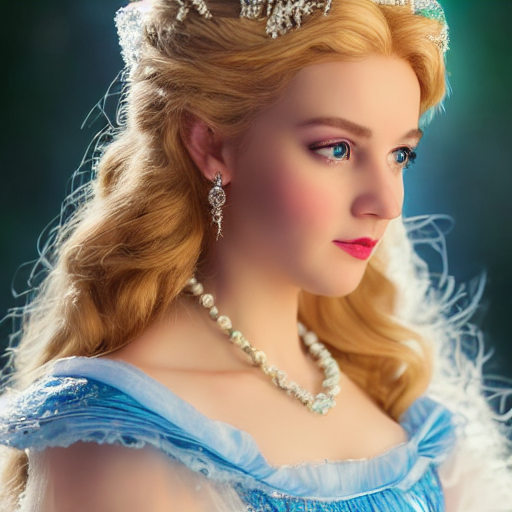

In [18]:
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(image)

Step 6:Save the generated image

In [20]:
image.save("generated_human_face.png")